In [12]:
import pandas as pd
from seaborn import lineplot

from visualisierungen import *

In [13]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr             rechtsform_name  \
0  1.0  1848-09-12  1848-1851  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  berecht  ...  zustimmung_p-vdk  zustimmung_p-sodk  \
0      1.0        72.83      NaN  ...               NaN                NaN   
1      0.0    

# Postion-Bundesrat vs. Zustimmung

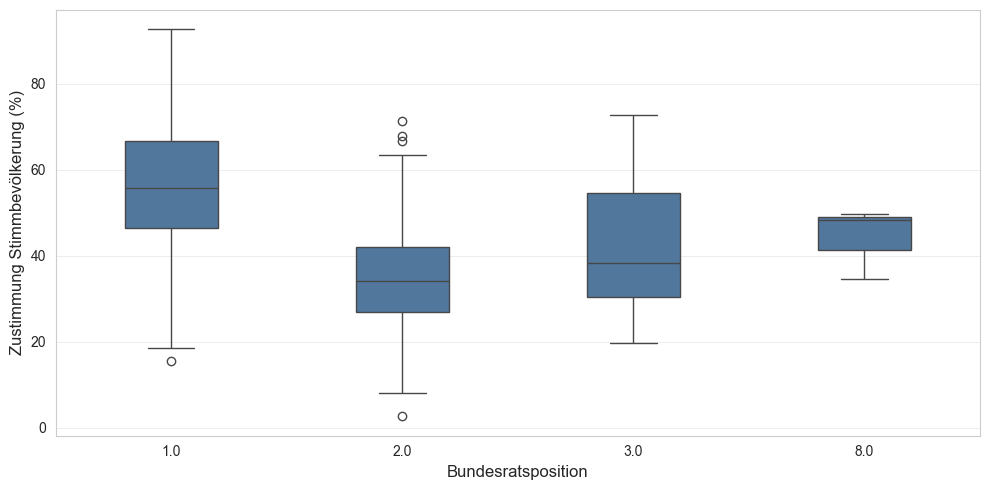

In [14]:
boxplot(df, df["br-pos"], df["volkja-proz"], titel="", xlabel="Bundesratsposition", ylabel="Zustimmung Stimmbevölkerung (%)", farbe=None)


# Zeitliche Dimension

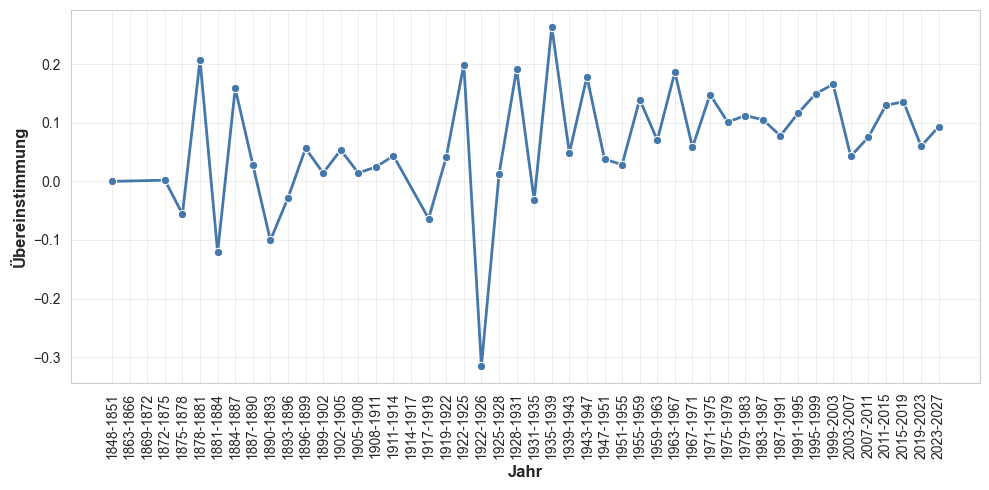

In [15]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:317: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


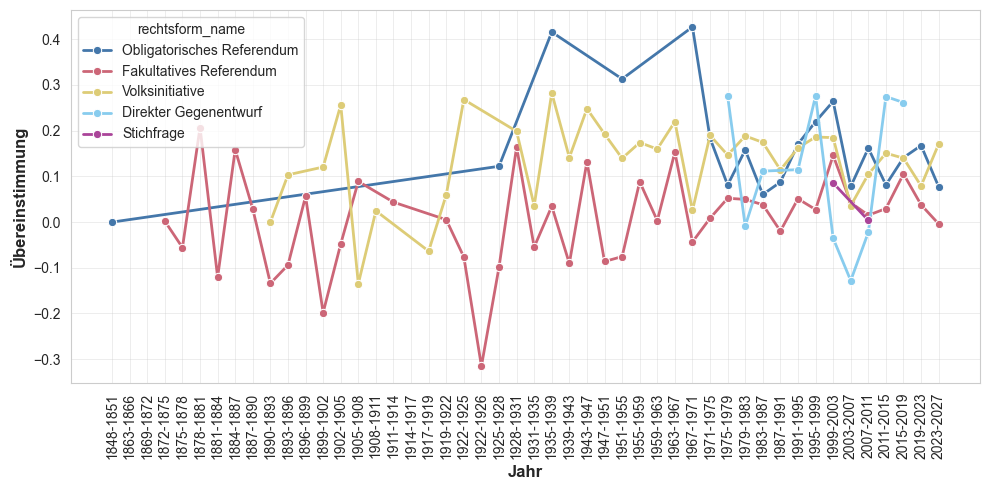

In [16]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, hue="rechtsform_name", errorbar=None)

In [17]:
df.head(50)

,anr,datum,legisjahr,rechtsform_name,titel_kurz_d,anzahl,beteiligung,annahme,volkja-proz,berecht,...,zustimmung_p-vdk,zustimmung_p-sodk,zustimmung_p-endk,zustimmung_p-fdk,zustimmung_p-edk,zustimmung_p-bpuk,zustimmung_anneepolitique,zustimmung_curiavista-de,zustimmung_swissvoteslink,zustimmung_rechtsform
0,1.0,1848-09-12,1848-1851,Obligatorisches Referendum,Bundesverfassung der schweizerischen Eidgenoss...,1,NaN,1.0,72.83,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2283
1,2.0,1866-01-14,1863-1866,Obligatorisches Referendum,Mass und Gewicht,9,NaN,0.0,50.44,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0044
2,3.0,1866-01-14,1863-1866,Obligatorisches Referendum,Gleichstellung der Juden und Naturalisierten m...,9,NaN,1.0,53.23,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0323
3,4.0,1866-01-14,1863-1866,Obligatorisches Referendum,Stimmrecht der Niedergelassenen in Gemeindeang...,9,NaN,0.0,43.08,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0692
4,5.0,1866-01-14,1863-1866,Obligatorisches Referendum,Besteuerung und zivilrechtliche Verhältnisse d...,9,NaN,0.0,39.88,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1012
5,6.0,1866-01-14,1863-1866,Obligatorisches Referendum,Stimmrecht der Niedergelassenen in kantonalen ...,9,NaN,0.0,48.09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0191
6,7.0,1866-01-14,1863-1866,Obligatorisches Referendum,Glaubens- und Kultusfreiheit,9,NaN,0.0,49.16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0084
7,8.0,1866-01-14,1863-1866,Obligatorisches Referendum,Ausschliessung einzelner Strafarten,9,NaN,0.0,34.19,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.1581
8,9.0,1866-01-14,1863-1866,Obligatorisches Referendum,Schutz des geistigen Eigentums,9,NaN,0.0,43.66,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0634
9,10.0,1866-01-14,1863-1866,Obligatorisches Referendum,Verbot der Lotterie und Hasardspiele,9,NaN,0.0,44.03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0597


/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:317: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.lineplot(


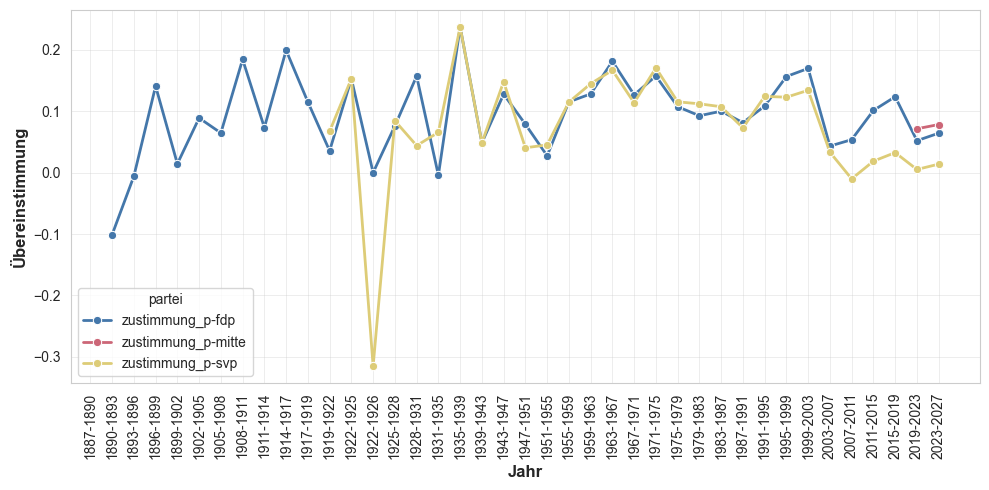

In [22]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte"]

df_long = df[["legisjahr"] + partei_cols].melt(
    id_vars="legisjahr", var_name="partei", value_name="zustimmung")

df_long_mean = df_long.groupby(["legisjahr", "partei"])["zustimmung"].mean().reset_index()

liniendiagramm(df_long_mean, x="legisjahr", y="zustimmung", hue="partei",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90)